In [1]:
#Import needed packages
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 34.3 MB/s  0:00:00 35.9 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for numpy: filename=numpy-2.2.0-cp314-cp314-macosx_26_0_arm64.whl size=5183380 sha256=6520ac79921e87ba93dc2a4a52101791256bcb447723ba6219f2ed0e30d0b32c
  Stored in directory: /Users/mahaahmedabujabal/Library/Caches/pip/wheels/5e/f8/5c/cb4d7e4a721b4d1e9fea17a7f248e8794921c3a451bac0d408
Successfully built numpy
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 3.0.3 requires numpy>=2.3.3; python_version >= "3.14", but you hav

In [2]:
# import libraries.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [3]:
#Load the data using pandas library 
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df=pd.read_csv(url)


In [4]:
# verify successful load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
222,2014,CHEVROLET,EXPRESS 1500 PASSENGER AWD,VAN - PASSENGER,5.3,8,A4,E,25.3,19.3,22.6,12,362
393,2014,FORD,FIESTA,SUBCOMPACT,1.6,4,M5,X,8.6,6.4,7.6,37,175
836,2014,NISSAN,ALTIMA,MID-SIZE,2.5,4,AV,X,8.7,6.2,7.6,37,175
126,2014,BMW,X1 xDRIVE28i,SUV - SMALL,2.0,4,A8,Z,10.6,7.2,9.1,31,209
969,2014,TOYOTA,CAMRY,MID-SIZE,3.5,6,AS6,X,11.1,7.8,9.6,29,221


In [ ]:
'''
Understand the data
FuelConsumption.csv:
You will use a fuel consumption dataset, FuelConsumption.csv, which contains 
model-specific fuel consumption ratings and estimated carbon dioxide emissions 
for new light-duty vehicles for retail sale in Canada. Dataset source.

MODEL YEAR e.g. 2014
MAKE e.g. VOLVO
MODEL e.g. S60 AWD
VEHICLE CLASS e.g. COMPACT
ENGINE SIZE e.g. 3.0
CYLINDERS e.g 6
TRANSMISSION e.g. AS6
FUEL TYPE e.g. Z
FUEL CONSUMPTION in CITY(L/100 km) e.g. 13.2
FUEL CONSUMPTION in HWY (L/100 km) e.g. 9.5
FUEL CONSUMPTION COMBINED (L/100 km) e.g. 11.5
FUEL CONSUMPTION COMBINED MPG (MPG) e.g. 25
CO2 EMISSIONS (g/km) e.g. 182
Your task will be to create a simple linear regression model from one of these features 
to predict CO2 emissions of unobserved cars based on that feature.

'''

In [5]:
#Explore the data
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [6]:
#Select features
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
152,2.4,4,8.2,189
55,3.0,6,11.4,262
243,4.3,6,17.8,285
44,4.2,8,14.6,336
929,2.0,4,8.4,193
373,3.5,6,13.4,308
844,3.8,6,12.9,297
358,2.5,4,9.4,216
821,2.0,4,11.6,267


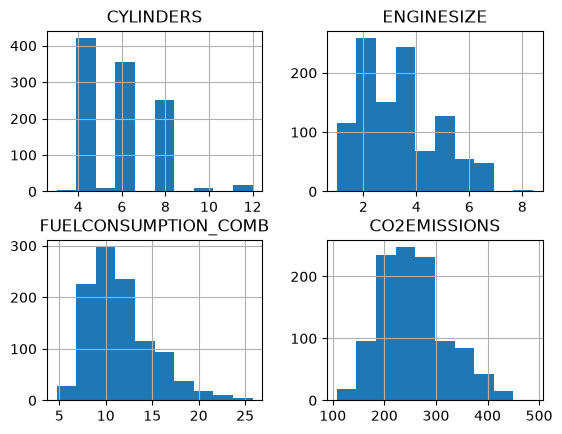

In [7]:
#Visualize features
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

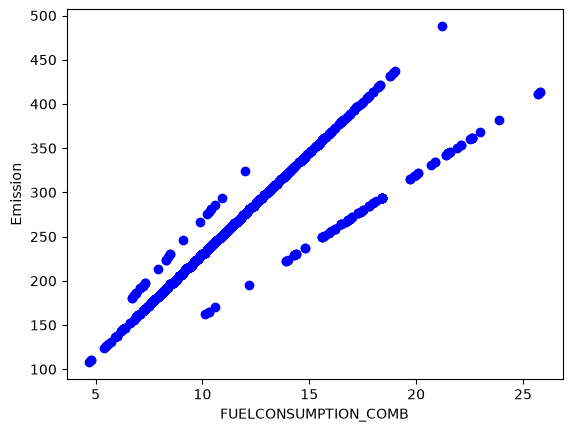

In [8]:
#Visualize features
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

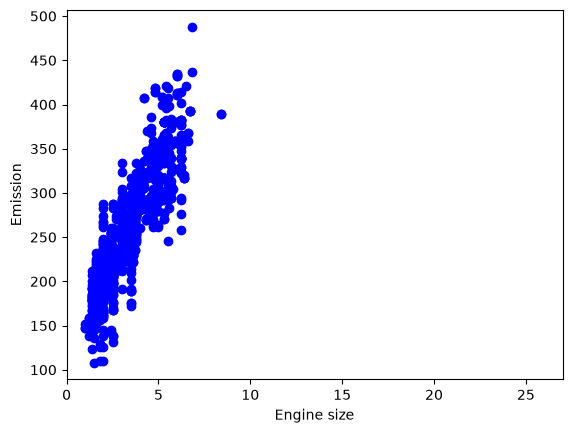

In [9]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

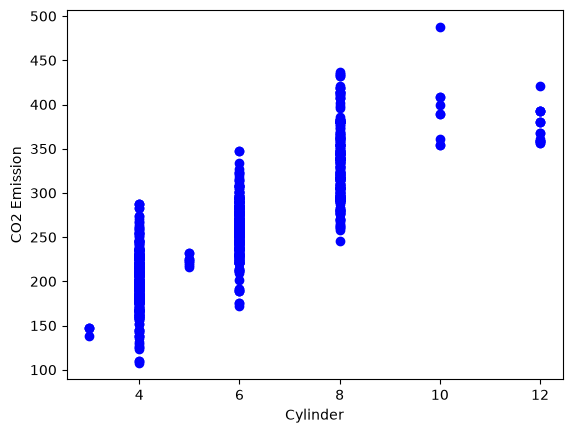

In [12]:
#Practice excercise 1
#Plot CYLINDER against CO2 Emission, to see how linear their relationship is.
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color="blue")
plt.xlabel("Cylinder")
plt.ylabel("CO2 Emission")
plt.show()
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

In [22]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات إلى 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# train the model on the training data
regressor.fit(X_train.reshape(-1, 1), y_train)

# Print the coefficients
print("Coefficients: ", regressor.coef_[0])
print("Intercept: ", regressor.intercept_)

Coefficients:  38.99297872443395
Intercept:  126.28970217408764


Text(0, 0.5, 'Emission')

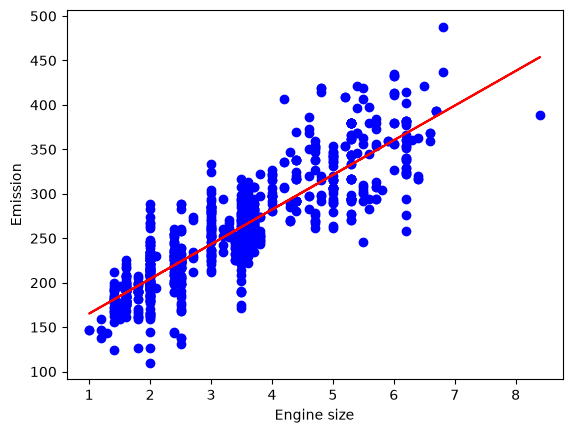

In [24]:
#Visualize model outputs
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [ ]:
'''
Model evaluation
You can compare the actual values and predicted values to calculate the accuracy of a
regression model. 
Evaluation metrics play a key role in the development of a model,
as they provide insight into areas that requires improvments 
There are different model evaluation metrics,
let's use MSE here to calculate the accuracy of our model based on the test set:

Mean Absolute Error:
It is the mean of the absolute value of the errors.
This is the easiest of the metrics to understand since it’s just an average error.

Mean Squared Error (MSE):
MSE is the mean of the squared error. In fact, it's the metric used by the model
to find the best fit line, and for that reason,
it is also called the residual sum of squares.

Root Mean Squared Error (RMSE).
RMSE simply transforms the MSE into the same units as the variables being compared,
which can make it easier to interpret.

R2-Score
is not an error but rather a popular metric used to estimate the performance of your 
regression model. 
It represents how close the data points are to the fitted regression line.
The higher the R2-Score value, the better the model fits your data. 
The best possible score is 1.0 and it can be negative
(because the model can be arbitrarily worse).
'''

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


Text(0, 0.5, 'Emission')

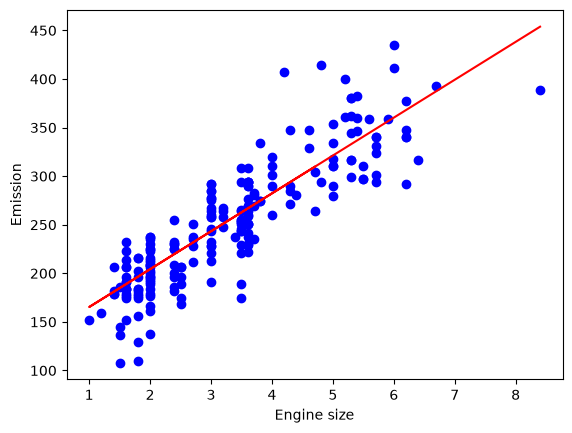

In [26]:
#1. Plot the regression model result over the test data instead
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test+ regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [27]:
#2. Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets
X = cdf.FUELCONSUMPTION_COMB.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
#3. Train a linear regression model using the training data you created
# X_train is a 1-D array but sklearn models expect a 2D array as input for the training data, with shape (n_observations, n_features).
# So we need to reshape it. We can let it infer the number of observations using '-1'.
regressor = linear_model.LinearRegression()
regressor.fit(X_train.reshape(-1, 1), y_train)


LinearRegression()

In [31]:
#Use the model to make test predictions on the fuel consumption testing data
y_pred = regressor.predict(X_test.reshape(-1,1))

In [30]:
#5. Calculate and print the Mean Squared Error of the test predictions
from sklearn.metrics import mean_squared_error
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))


Mean squared error: 797.43
